In [83]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [140]:
root_data = Path("./data")

keywords = ["data", "queich"]
csv_paths = [
    f for f in root_data.rglob("*.csv") 
    if any(k in f.name for k in keywords)
    ]
csv_paths

[WindowsPath('data/abfluss_queich_siebeldingen/data/abfluss_queich_siebeldingen.csv'),
 WindowsPath('data/precipitation_dahn/data/data_OBS_DEU_P1D_RR.csv'),
 WindowsPath('data/precipitation_pirmasens/data/data_3939.csv'),
 WindowsPath('data/snow_dahn/data/data_OBS_DEU_P1D_SH-N_19797.csv'),
 WindowsPath('data/temp_mean_2m_pirmasens/data/data_3939.csv')]

In [141]:
df_dict = {p.parent.parent.stem: pd.read_csv(filepath_or_buffer=p, sep=",", index_col=False) for p in csv_paths}

In [145]:
df_dict["abfluss_queich_siebeldingen"]["Parameter"].unique()

array(['Wasserstand am Pegel', 'Abfluss am Pegel'], dtype=object)

In [ ]:
df_queich = df_dict["abfluss_queich_siebeldingen"]
df_discharge = df_queich[df_queich["Parameter"] == "Abfluss am Pegel"]


In [154]:
df_discharge[["Datum", "Wert"]]

,Datum,Wert
1,01.03.1956,"1,896"
3,02.03.1956,"2,186"
5,03.03.1956,"3,7694"
7,04.03.1956,"3,123"
9,05.03.1956,"1,896"
...,...,...
51099,13.03.2026,"1,5824"
51101,14.03.2026,"1,7092"
51103,15.03.2026,"1,5798"
51105,16.03.2026,"1,637"


In [156]:
df_series_dict = {}
for key, df in df_dict.items():
    if key != "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Zeitstempel"])
        df_series.index = pd.to_datetime(df_series.index)
        df_series_dict[key] = df_series
        
    if key == "abfluss_queich_siebeldingen":
        df_series = pd.Series(df["Wert"].values, index=df["Datum"])
        df_series.index = pd.to_datetime(df_series.index, format="%d.%m.%Y")
        df_series_dict[key] = df_series

In [157]:
df_series_dict.keys()

dict_keys(['abfluss_queich_siebeldingen', 'precipitation_dahn', 'precipitation_pirmasens', 'snow_dahn', 'temp_mean_2m_pirmasens'])

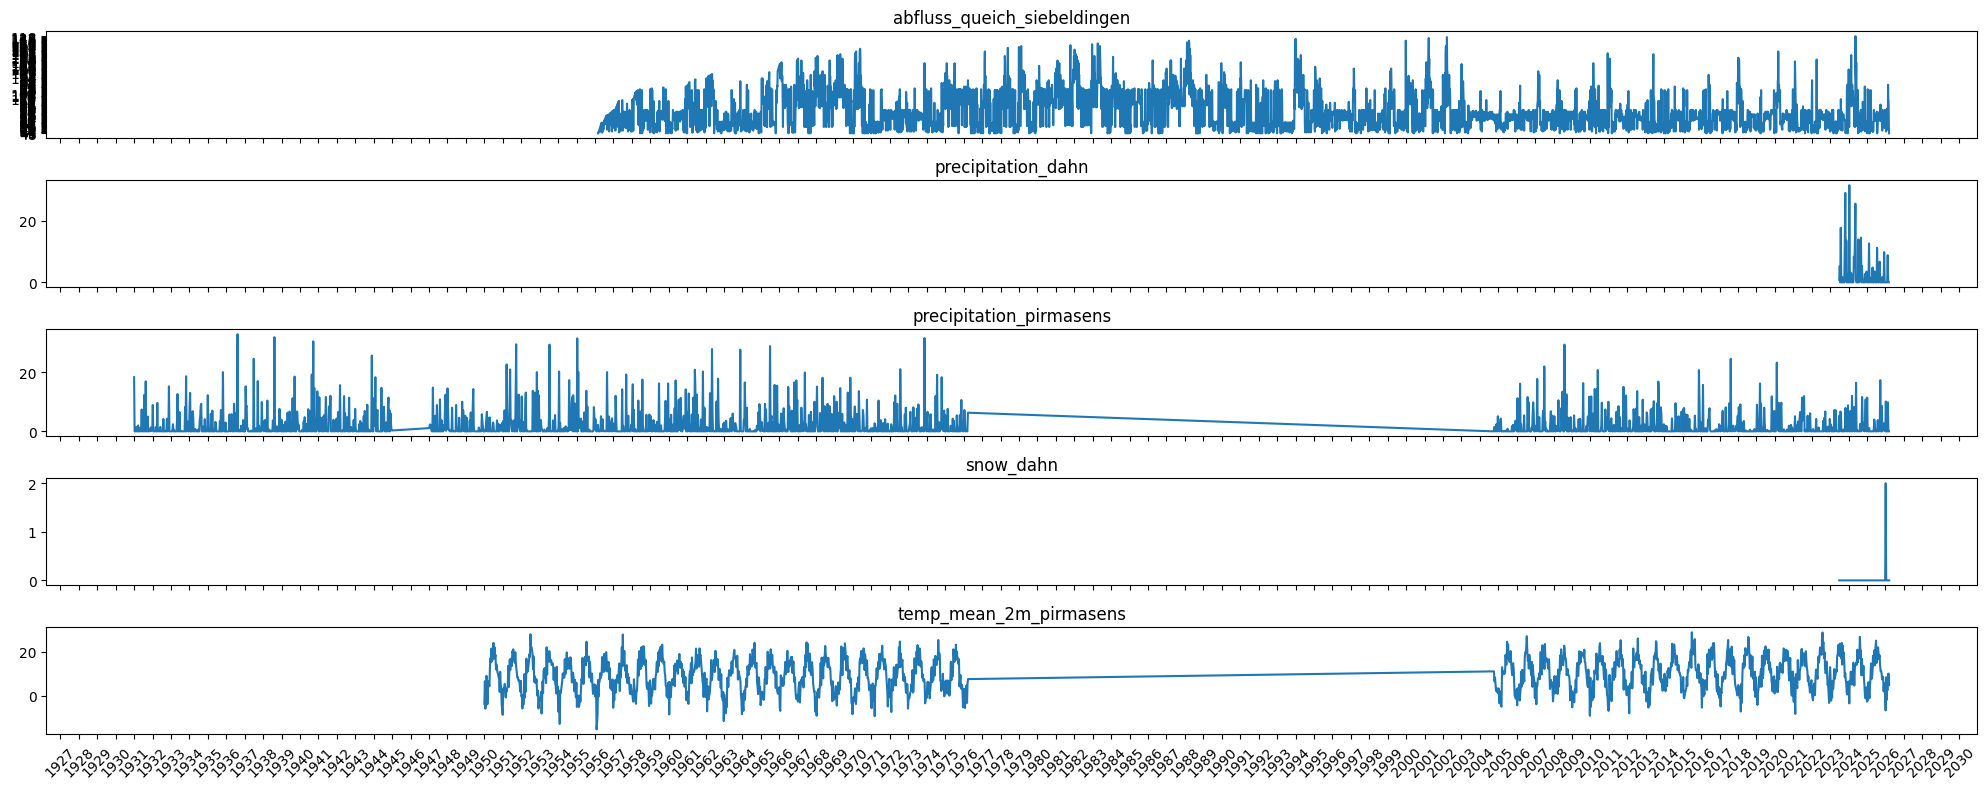

In [160]:
fig, ax = plt.subplots(nrows=5, figsize=(20, 8), sharex=True)
# ax = ax.flatten()

for i, (key, df) in enumerate(df_series_dict.items()):
    df = df[::10]
    
    ax[i].plot(df)

    # Set monthly ticks
    ax[i].xaxis.set_major_locator(mdates.YearLocator())
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax[i].tick_params(axis="x", rotation=45)
    
    ax[i].set_title(key)

plt.tight_layout()
plt.show()